<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/02_airbnb_nyc_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [14]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/AB_NYC_2019.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [15]:
df.shape

(48895, 16)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [17]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**2. Data Cleaning**

In [18]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
last_review,10052
reviews_per_month,10052
host_name,21
name,16
neighbourhood_group,0
neighbourhood,0
id,0
host_id,0
longitude,0
latitude,0


In [19]:
# reviews_per_month: no reviews = 0, not missing
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# last_review: convert to datetime, leave missing as NaT (means never reviewed)
df['last_review'] = pd.to_datetime(df['last_review'])

# name / host_name: fill with 'Unknown' (few missing, not critical for numeric analysis)
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [20]:
# Drop irrelevant columns
df = df.drop(columns=['id', 'host_id'])

In [21]:
# Check price distribution for outliers
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [22]:
# How many listings have price = 0? These are invalid
(df['price'] == 0).sum()

np.int64(11)

In [23]:
# Remove price = 0 (invalid listings)
df = df[df['price'] > 0]

# Cap extreme outliers at 99th percentile instead of dropping — preserves more data
upper_limit = df['price'].quantile(0.99)
print(f"99th percentile price: {upper_limit}")

df_clean = df[df['price'] <= upper_limit].copy()
print(df.shape, "->", df_clean.shape)

99th percentile price: 799.0
(48884, 14) -> (48410, 14)


In [24]:
# minimum_nights also has extreme outliers (e.g., 1000+ nights)
df_clean['minimum_nights'].describe()

,minimum_nights
count,48410.000000
mean,6.979508
std,20.293249
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1250.000000


In [25]:
# Cap minimum_nights similarly
min_nights_cap = df_clean['minimum_nights'].quantile(0.99)
df_clean = df_clean[df_clean['minimum_nights'] <= min_nights_cap]
df_clean.shape

(47928, 14)

**3. Univariate Analysis**

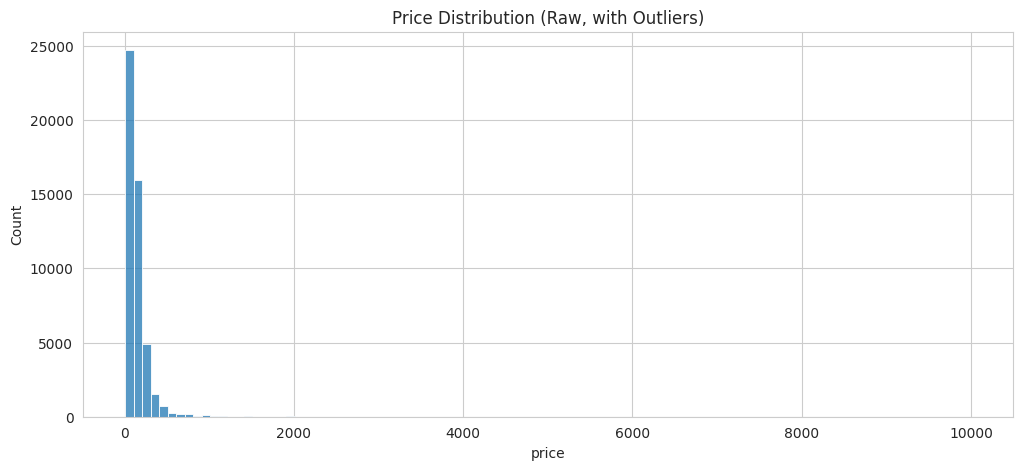

In [26]:
# Price distribution - before outlier removal
plt.figure(figsize=(12,5))
sns.histplot(df['price'], bins=100)
plt.title('Price Distribution (Raw, with Outliers)')
plt.show()

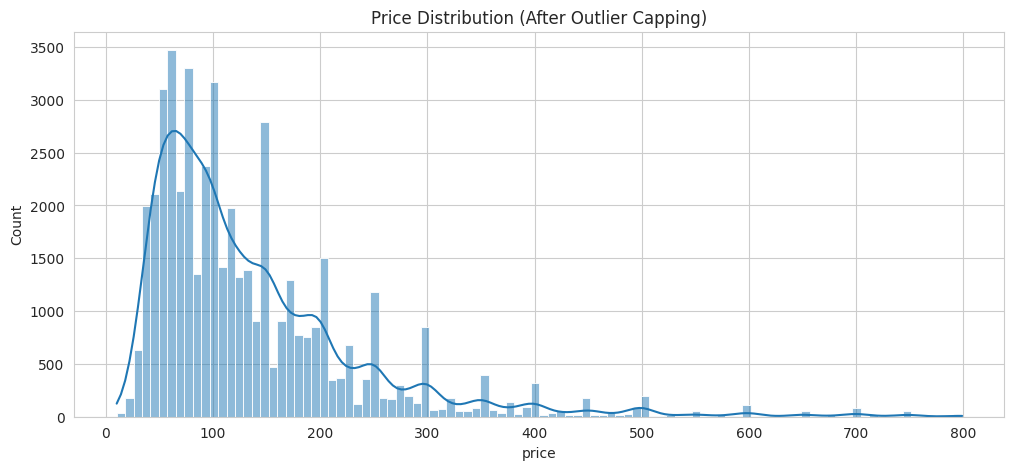

In [27]:
# Price distribution - after cleaning
plt.figure(figsize=(12,5))
sns.histplot(df_clean['price'], bins=100, kde=True)
plt.title('Price Distribution (After Outlier Capping)')
plt.show()

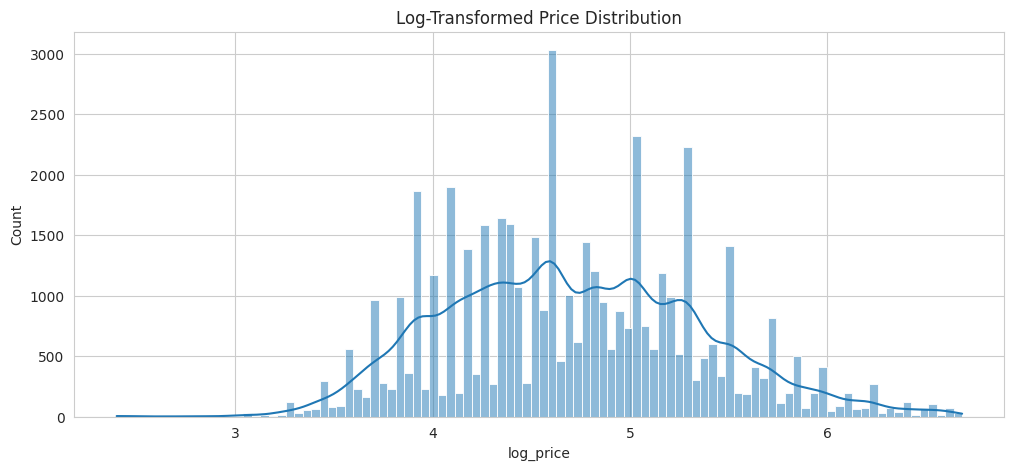

In [28]:
# Log transform to handle skew - common numeric EDA technique
df_clean['log_price'] = np.log1p(df_clean['price'])

plt.figure(figsize=(12,5))
sns.histplot(df_clean['log_price'], bins=100, kde=True)
plt.title('Log-Transformed Price Distribution')
plt.show()

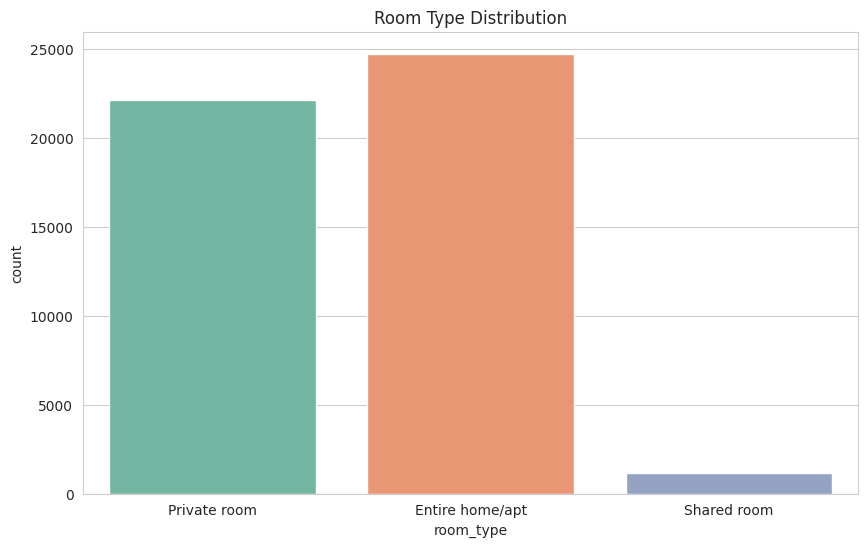

In [30]:
# Room type distribution
sns.countplot(data=df_clean, x='room_type', hue='room_type', palette='Set2', legend=False)
plt.title('Room Type Distribution')
plt.show()

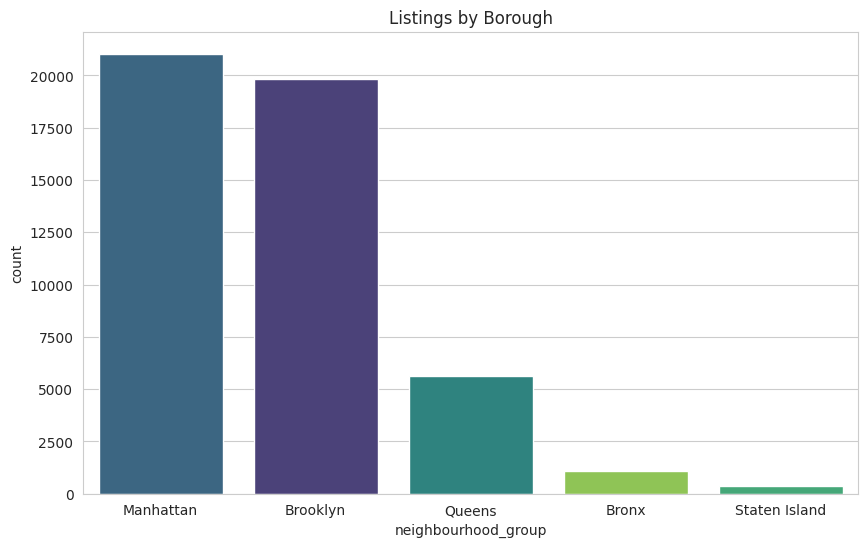

In [31]:
# Neighbourhood group distribution
sns.countplot(data=df_clean, x='neighbourhood_group', hue='neighbourhood_group',
              order=df_clean['neighbourhood_group'].value_counts().index, palette='viridis', legend=False)
plt.title('Listings by Borough')
plt.show()

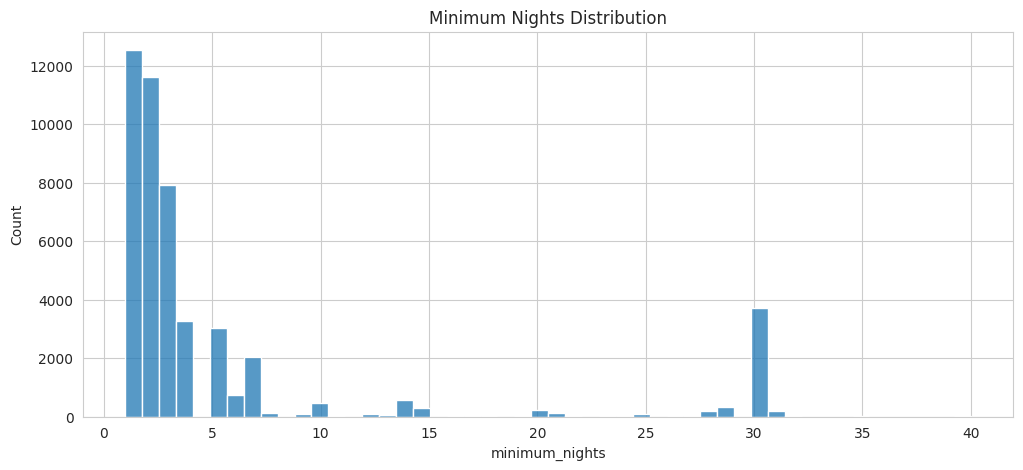

In [32]:
# Minimum nights distribution
plt.figure(figsize=(12,5))
sns.histplot(df_clean['minimum_nights'], bins=50)
plt.title('Minimum Nights Distribution')
plt.show()

**4. Bivariate / Multivariate Analysis**

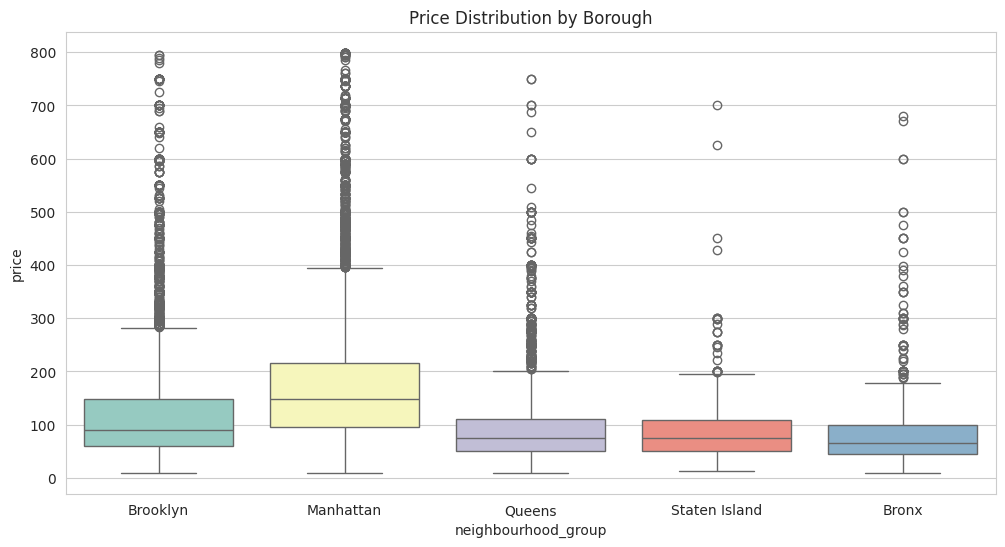

In [33]:
# Price by borough
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='neighbourhood_group', y='price', hue='neighbourhood_group', palette='Set3', legend=False)
plt.title('Price Distribution by Borough')
plt.show()

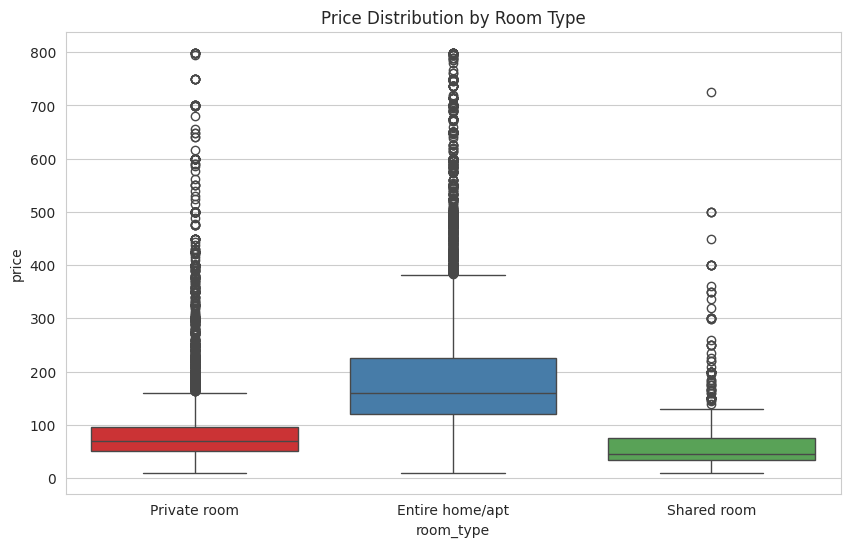

In [35]:
# Price by room type
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='room_type', y='price', hue='room_type', palette='Set1', legend=False)
plt.title('Price Distribution by Room Type')
plt.show()

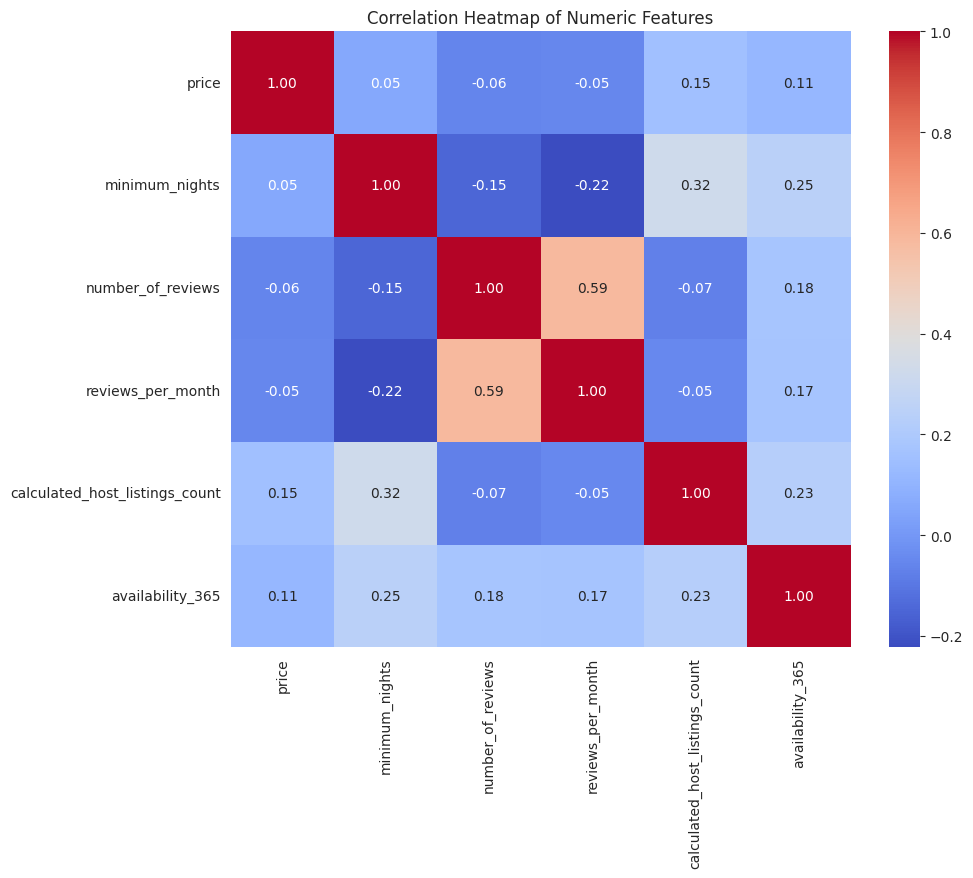

In [36]:
# Correlation heatmap
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                 'calculated_host_listings_count', 'availability_365']

plt.figure(figsize=(10,8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

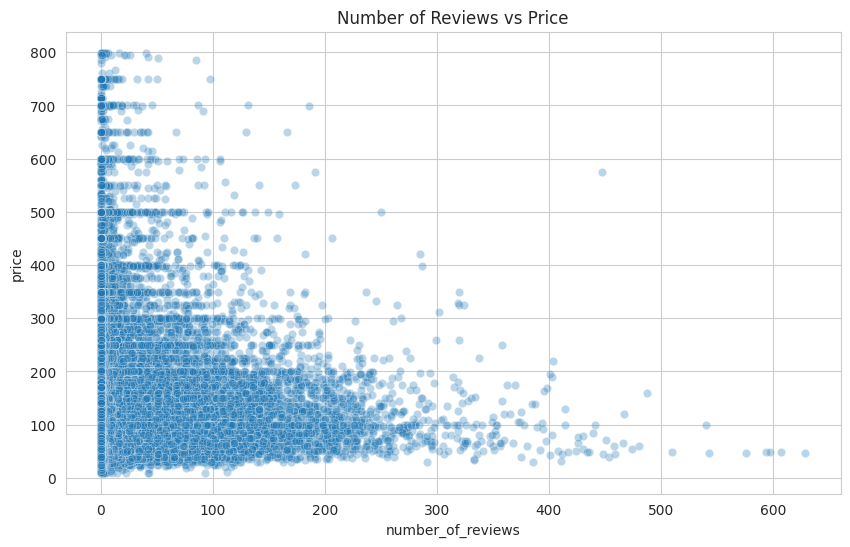

In [37]:
# Number of reviews vs price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='number_of_reviews', y='price', alpha=0.3)
plt.title('Number of Reviews vs Price')
plt.show()

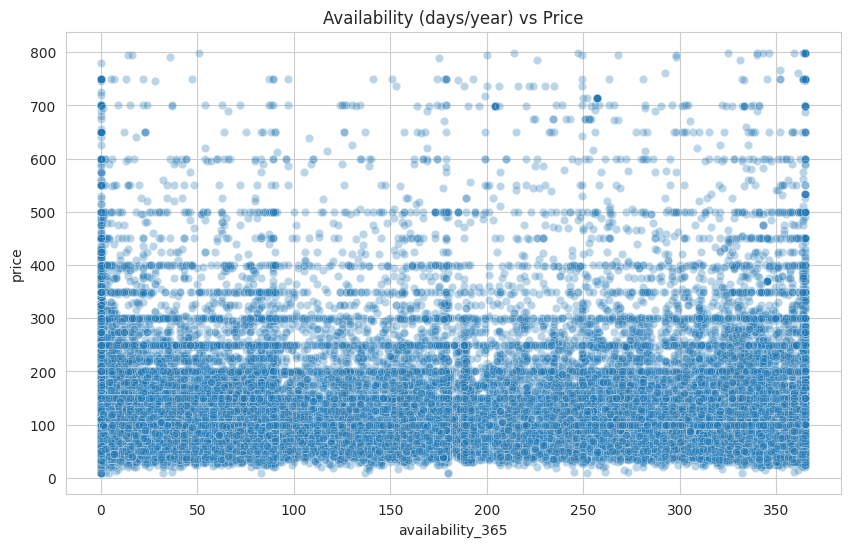

In [38]:
# Availability vs price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='availability_365', y='price', alpha=0.3)
plt.title('Availability (days/year) vs Price')
plt.show()

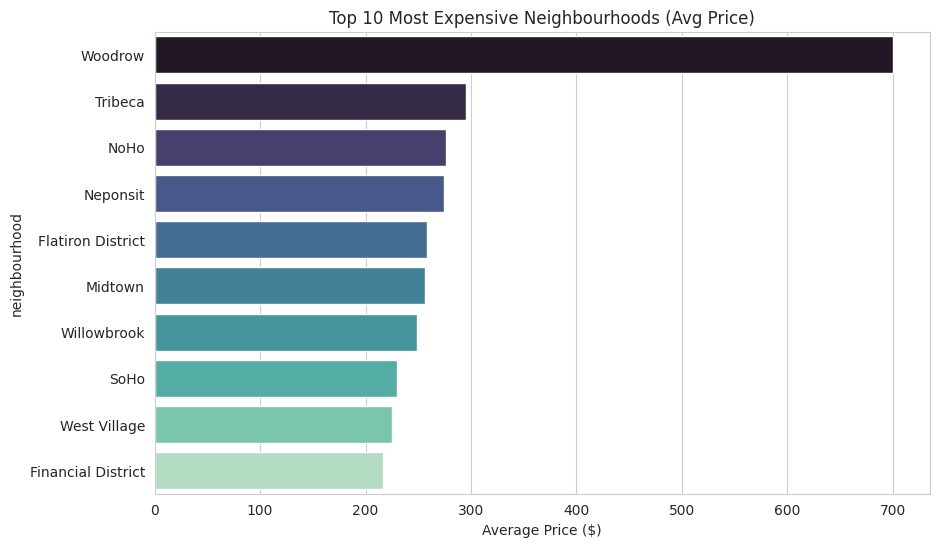

In [39]:
# Top 10 neighbourhoods by average price
top_neigh = df_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_neigh.values, y=top_neigh.index, hue=top_neigh.index, palette='mako', legend=False)
plt.title('Top 10 Most Expensive Neighbourhoods (Avg Price)')
plt.xlabel('Average Price ($)')
plt.show()

**5. Geospatial Angle**

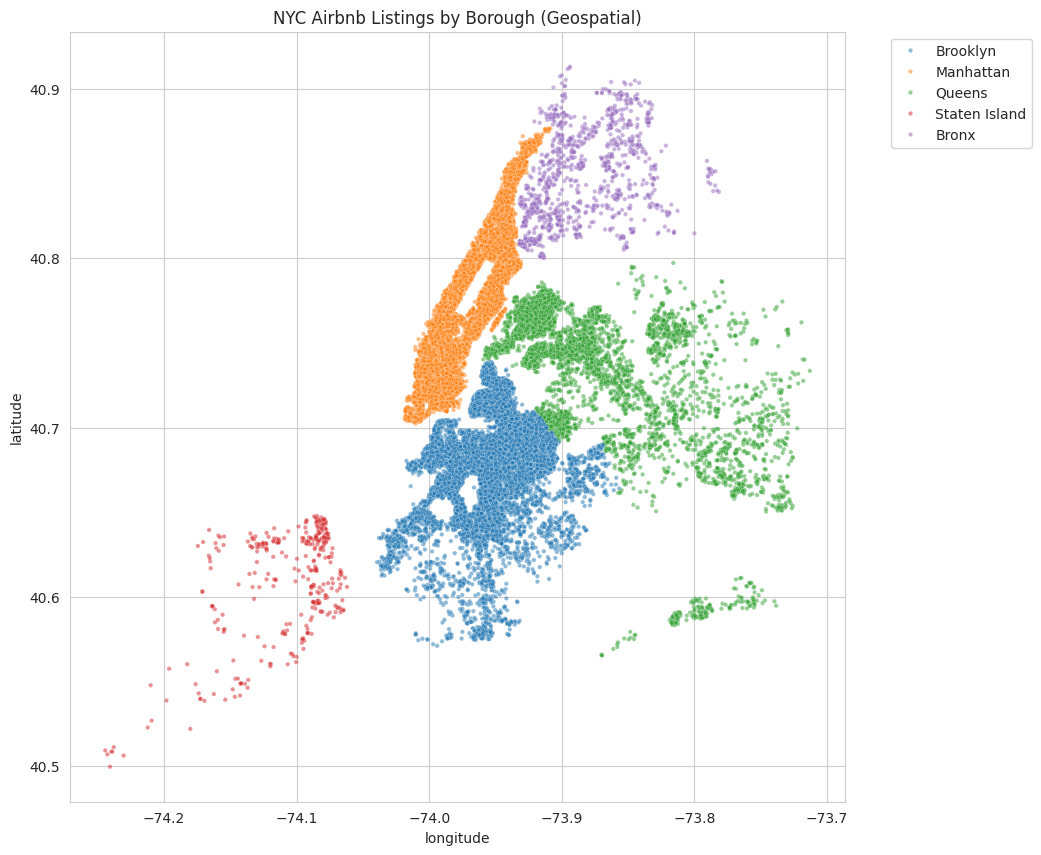

In [40]:
# Map-style scatterplot colored by neighbourhood group
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_clean, x='longitude', y='latitude',
                 hue='neighbourhood_group', s=10, alpha=0.5)
plt.title('NYC Airbnb Listings by Borough (Geospatial)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

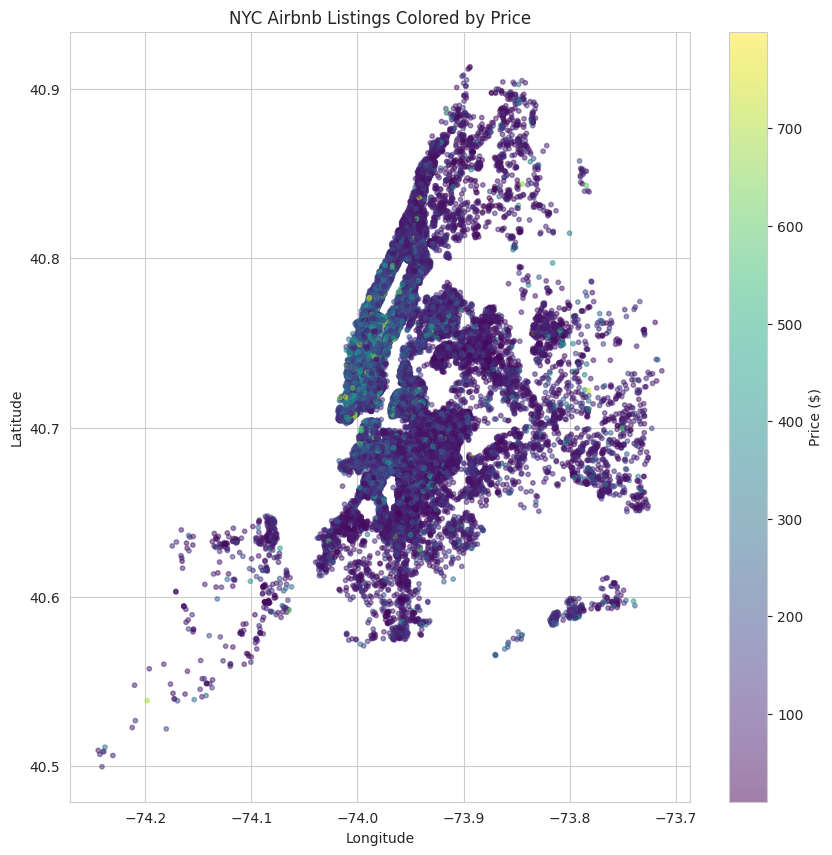

In [41]:
# Same map, colored by price (capped for visibility)
plt.figure(figsize=(10,10))
sc = plt.scatter(df_clean['longitude'], df_clean['latitude'],
                  c=df_clean['price'], cmap='viridis', s=10, alpha=0.5)
plt.colorbar(sc, label='Price ($)')
plt.title('NYC Airbnb Listings Colored by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**6. Insights Summary**

## Key Insights

- Manhattan has the highest average listing prices, followed by Brooklyn.
- Entire home/apartment listings are significantly more expensive than private or shared rooms.
- Price is not strongly correlated with number of reviews — cheaper listings don't necessarily get more bookings.
- Raw price data is heavily right-skewed with extreme outliers; log transformation normalizes it for further analysis.
- [Add specific neighbourhood you found most expensive]
- Listings cluster geographically by borough, visible clearly in the lat/long scatterplot.
- [Add 1-2 more insights based on what you actually observed]